# Example: Computing Trajectories for Each Transportation Mode

This notebook demonstrates how to use the `src` module to compute trajectories for **foot**, **bike**, and **car** modes. For each mode, we:

1. Query OSRM for a route between an origin and destination
2. Find street view images along the route
3. Calculate aggregated density features from those images

## 1. Setup and imports

In [1]:
import sys
sys.path.insert(0, 'src')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import Point

from trajectory_analysis import get_osrm_route, get_trajectory_images, calculate_trajectory_features

## 2. Load data

Load GTFS stations and street view images with DINOSAM density features.

In [2]:
from process_trajectories import load_data

gdf_st, gdf_img, df = load_data()
print(f"Stations: {len(gdf_st)}, Images: {len(gdf_img)}, Trips: {len(df)}")

Loading data...
  Loaded 579 stations


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fram

  Loaded 1689899 street view images


  Loaded 24293 valid trips
  non-valid rows: 0
Stations: 579, Images: 1689899, Trips: 24293


## 3. Pick a sample trip

Select one trip from the travel survey to use as our example.

In [3]:
row = df.iloc[0]

origin = row['p_home']
destination = row['home_station_geometry']

print(f"TurId: {row['TurId']}")
print(f"Origin (home):       {origin}")
print(f"Destination (station): {destination}")
print(f"Station name: {row['HOME_NearestStation']}")

TurId: 1086358
Origin (home):       POINT (12.158989677164987 55.90719192967548)
Destination (station): POINT (12.149240609197 55.907558706672)
Station name: Skævinge


## 4. Compute trajectories for each mode

Query OSRM for foot, bike, and car routes between the same origin-destination pair.

In [4]:
modes = ['foot', 'bike', 'car']
buffer_m = 20

results = {}
for mode in modes:
    result = get_trajectory_images(
        p_home=origin,
        home_station_geometry=destination,
        gdf_img=gdf_img,
        mode=mode,
        buffer_m=buffer_m,
    )
    results[mode] = result
    print(f"[{mode:4s}]  distance: {result['distance_m']:,.0f} m | "
          f"duration: {result['duration_s']:,.0f} s | "
          f"images found: {result['n_images']}")

[foot]  distance: 735 m | duration: 529 s | images found: 28
[bike]  distance: 747 m | duration: 215 s | images found: 31


[car ]  distance: 739 m | duration: 85 s | images found: 31


## 5. Visualize the routes on a map

Plot all three routes with the street view images found along each one.

/tmp/ipykernel_2947343/3748721366.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=7)


/tmp/ipykernel_2947343/3748721366.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=7)


/tmp/ipykernel_2947343/3748721366.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=7)


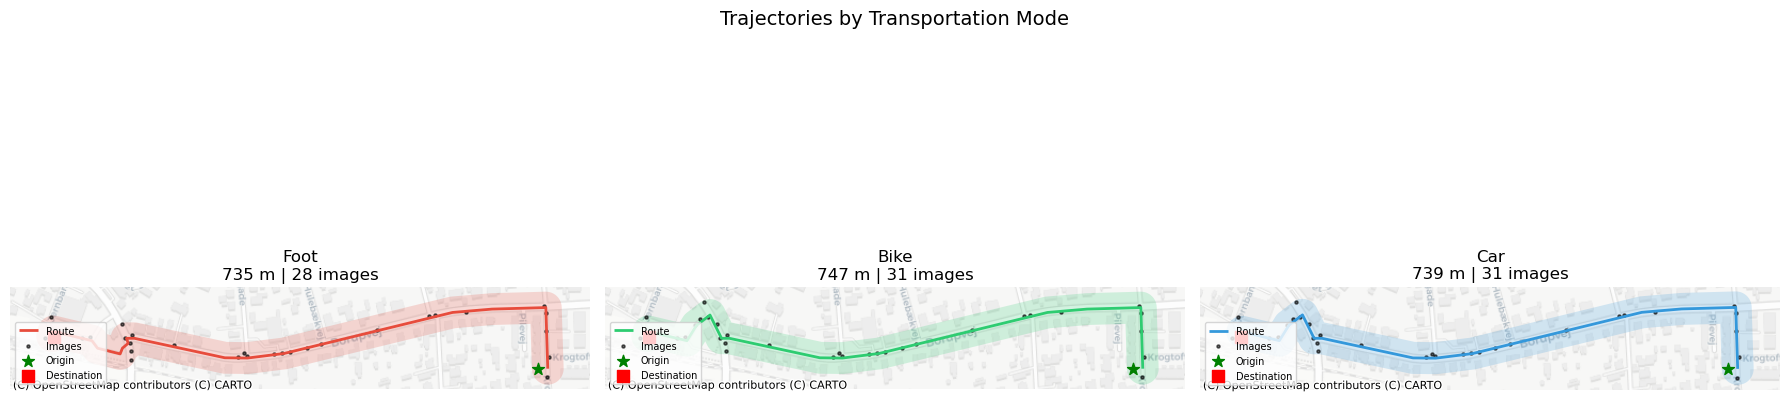

In [5]:
colors = {'foot': '#e74c3c', 'bike': '#2ecc71', 'car': '#3498db'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, mode in zip(axes, modes):
    result = results[mode]

    # Plot buffered trajectory
    result['trajectory'].plot(ax=ax, color=colors[mode], alpha=0.2, label='Buffer')

    # Plot route line (convert to EPSG:3857 for basemap)
    route_gdf = gpd.GeoDataFrame(geometry=[result['route_line']], crs='EPSG:4326').to_crs('EPSG:3857')
    route_gdf.plot(ax=ax, color=colors[mode], linewidth=2, label='Route')

    # Plot images found along route
    if result['n_images'] > 0:
        result['images'].plot(ax=ax, color='black', markersize=5, alpha=0.6, label='Images')

    # Plot origin and destination
    pts = gpd.GeoDataFrame(
        geometry=[origin, destination], crs='EPSG:4326'
    ).to_crs('EPSG:3857')
    pts.iloc[[0]].plot(ax=ax, color='green', markersize=80, marker='*', zorder=5, label='Origin')
    pts.iloc[[1]].plot(ax=ax, color='red', markersize=80, marker='s', zorder=5, label='Destination')

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
    ax.set_title(f"{mode.capitalize()}\n{result['distance_m']:,.0f} m | {result['n_images']} images")
    ax.set_axis_off()
    ax.legend(loc='lower left', fontsize=7)

plt.suptitle('Trajectories by Transportation Mode', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Calculate density features per mode

Extract aggregated density statistics (mean, median, std, min, max) from the street view images along each trajectory.

In [6]:
features_by_mode = {}
for mode in modes:
    features = calculate_trajectory_features(results[mode])
    features_by_mode[mode] = features

# Show a summary of key features
summary_cols = ['distance_m', 'duration_s', 'n_images',
                'greens_density_mean', 'buildings_density_mean',
                'road_density_mean', 'sidewalk_density_mean',
                'car_density_mean', 'person_density_mean']

summary = pd.DataFrame({
    mode: {col: features_by_mode[mode].get(col, np.nan) for col in summary_cols}
    for mode in modes
})
summary

,foot,bike,car
distance_m,735.300000,747.200000,738.900000
duration_s,529.400000,214.900000,84.900000
n_images,28.000000,31.000000,31.000000
greens_density_mean,0.068031,0.069289,0.069289
buildings_density_mean,0.037871,0.037896,0.037896
road_density_mean,0.355798,0.356156,0.356156
sidewalk_density_mean,0.025828,0.027163,0.027163
car_density_mean,0.001398,0.001701,0.001701
person_density_mean,0.000018,0.000017,0.000017


## 7. Compare density features across modes

Visualize how the urban environment differs along each route.

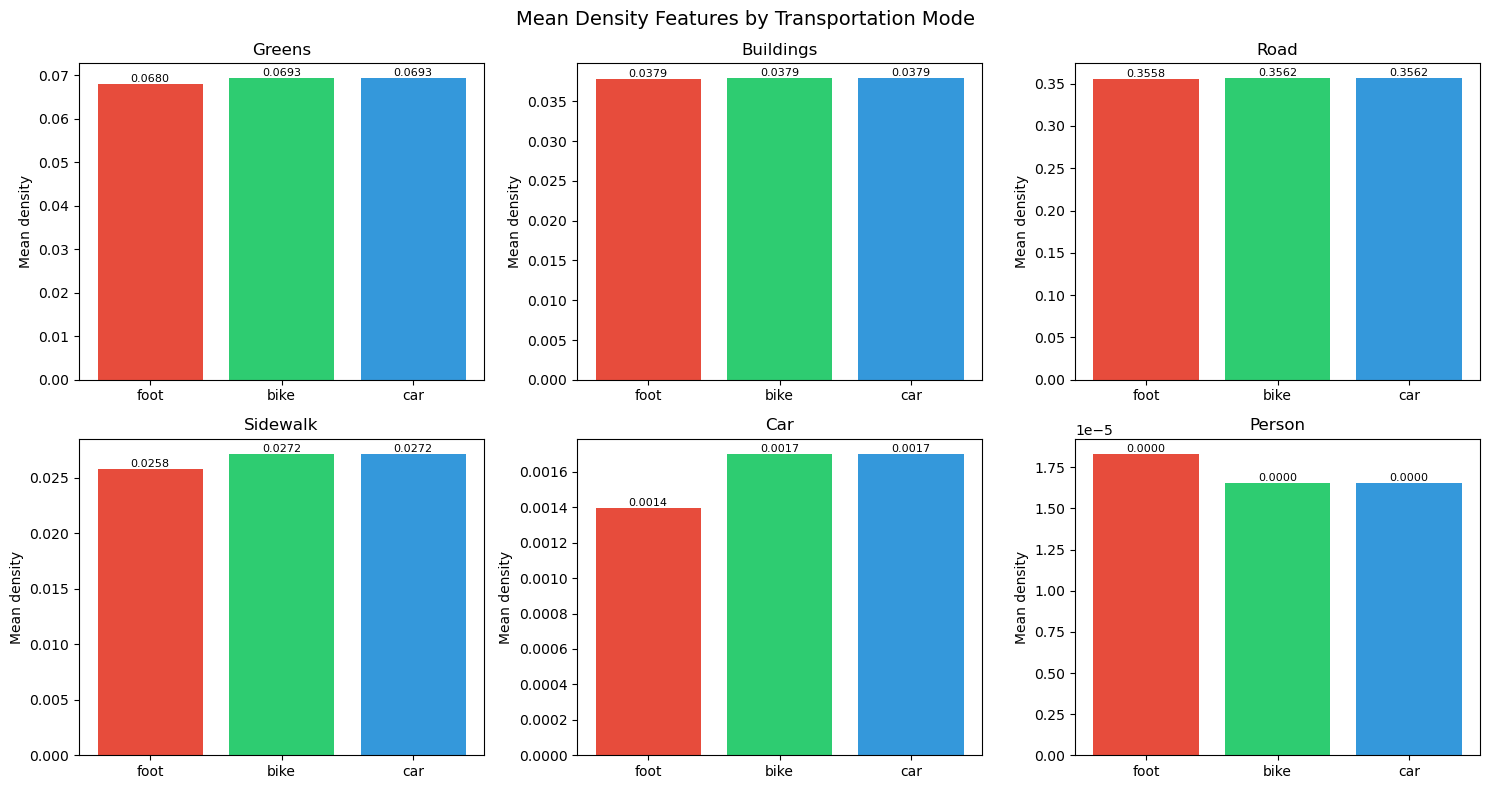

In [7]:
compare_features = ['greens_density', 'buildings_density', 'road_density',
                     'sidewalk_density', 'car_density', 'person_density']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feat in zip(axes.flat, compare_features):
    means = [features_by_mode[m].get(f'{feat}_mean', 0) for m in modes]
    bars = ax.bar(modes, means, color=[colors[m] for m in modes])
    ax.set_title(feat.replace('_density', '').replace('_', ' ').title())
    ax.set_ylabel('Mean density')
    ax.bar_label(bars, fmt='%.4f', fontsize=8)

plt.suptitle('Mean Density Features by Transportation Mode', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Batch processing: multiple trips across all modes

Process a small batch of trips for all three modes using `process_trajectories`.

In [8]:
from process_trajectories import process_trajectories

batch_results = {}
for mode in modes:
    print(f"\n--- {mode.upper()} ---")
    batch_results[mode] = process_trajectories(df, gdf_img, mode=mode, buffer_m=20, limit=5)


--- FOOT ---
Processing first 5 trips...


Processing routes:   0%|          | 0/5 [00:00<?, ?it/s]

Processing routes:  20%|██        | 1/5 [00:00<00:02,  1.38it/s]

Processing routes:  40%|████      | 2/5 [00:01<00:02,  1.44it/s]

Processing routes:  60%|██████    | 3/5 [00:02<00:01,  1.46it/s]

...

Processing routes:  60%|██████    | 3/5 [00:02<00:01,  1.46it/s]

Processing routes:  80%|████████  | 4/5 [00:02<00:00,  1.46it/s]

Processing routes: 100%|██████████| 5/5 [00:03<00:00,  1.46it/s]

Processing routes: 100%|██████████| 5/5 [00:03<00:00,  1.45it/s]


Successfully processed 5 trajectories


In [9]:
# Compare average distances and durations across modes for the batch
batch_summary = pd.DataFrame({
    mode: {
        'mean_home_distance_m': batch_results[mode]['home_distance_m'].mean(),
        'mean_home_duration_s': batch_results[mode]['home_duration_s'].mean(),
        'mean_home_n_images': batch_results[mode]['home_n_images'].mean(),
        'mean_act_distance_m': batch_results[mode]['act_distance_m'].mean(),
        'mean_act_duration_s': batch_results[mode]['act_duration_s'].mean(),
        'mean_act_n_images': batch_results[mode]['act_n_images'].mean(),
    }
    for mode in modes
})
batch_summary

,foot,bike,car
mean_home_distance_m,506.94,512.06,1398.66
mean_home_duration_s,366.50,201.20,166.64
mean_home_n_images,17.20,19.80,59.40
mean_act_distance_m,1349.46,1472.00,1486.14
mean_act_duration_s,973.28,429.22,156.04
mean_act_n_images,40.40,57.80,57.20
